In [74]:
!pip install kaggle -q

In [75]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


**Importing the Dependencies**

In [76]:
import os
import json

import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

**Data Collection**

In [77]:
kaggle_config = json.load(open("kaggle.json"))  # login to kaggle > verify account > profile icon > settings > create new API token

In [78]:
kaggle_config.keys()

dict_keys(['username', 'key'])

In [79]:
# Set the environment variables
os.environ['KAGGLE_USERNAME'] = kaggle_config['username']
os.environ['KAGGLE_KEY'] = kaggle_config['key']

In [80]:
from kaggle.api.kaggle_api_extended import KaggleApi
# Authenticate
api = KaggleApi()
api.authenticate()

# Download dataset
api.dataset_download_files(
    'notshrirang/spotify-million-song-dataset',
    path='.',
    unzip=True
)

Dataset URL: https://www.kaggle.com/datasets/notshrirang/spotify-million-song-dataset


In [81]:
!ls

Music_Recommendation_System_using_Python.ipynb
kaggle.json
requirements.txt
spotify_millsongdata.csv
start_app.txt


In [82]:
# loading the dataset to a pandas dataframe
df = pd.read_csv("spotify_millsongdata.csv")

**Initial Understanding**

In [83]:
df.shape

(57650, 4)

In [84]:
df.head()

,artist,song,link,text
0,ABBA,Ahe's My Kind Of Girl,/a/abba/ahes+my+kind+of+girl_20598417.html,"Look at her face, it's a wonderful face \r\nA..."
1,ABBA,"Andante, Andante",/a/abba/andante+andante_20002708.html,"Take it easy with me, please \r\nTouch me gen..."
2,ABBA,As Good As New,/a/abba/as+good+as+new_20003033.html,I'll never know why I had to go \r\nWhy I had...
3,ABBA,Bang,/a/abba/bang_20598415.html,Making somebody happy is a question of give an...
4,ABBA,Bang-A-Boomerang,/a/abba/bang+a+boomerang_20002668.html,Making somebody happy is a question of give an...


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57650 entries, 0 to 57649
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   artist  57650 non-null  object
 1   song    57650 non-null  object
 2   link    57650 non-null  object
 3   text    57650 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB


In [86]:
df.isnull().sum()

artist    0
song      0
link      0
text      0
dtype: int64

In [87]:
# Top artists and songs
top_artists = df['artist'].value_counts().head(10)
print("\nTop 10 Artists:")
print(top_artists)


Top 10 Artists:
artist
Donna Summer        191
Gordon Lightfoot    189
Bob Dylan           188
George Strait       188
Loretta Lynn        187
Alabama             187
Cher                187
Reba Mcentire       187
Chaka Khan          186
Dean Martin         186
Name: count, dtype: int64


In [88]:
df = df.sample(10000)

df = df.drop('link', axis=1).reset_index(drop=True)

In [89]:
df.shape

(10000, 3)

In [90]:
df.head()

,artist,song,text
0,Kelly Family,Say That You Love Me,Oh my baby if I could only evoke the love \r\...
1,Black Sabbath,Feels Good To Me,The chapter is opened and the pages are turned...
2,The Killers,Uncle Jonny,When everybody else refrains \r\nMy uncle Jon...
3,Willie Nelson,Down To Our Last Goodbye,This was my last mistake \r\nThat's all her h...
4,Heart,Unchained Melody,"Oh, my love, my darling \r\nI've hungered for..."


In [91]:
# WordCloud for song lyrics (also fixing the missing values)
all_lyrics = " ".join(df['text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_lyrics)

WordCloud to visualize the most common words in the lyrics.

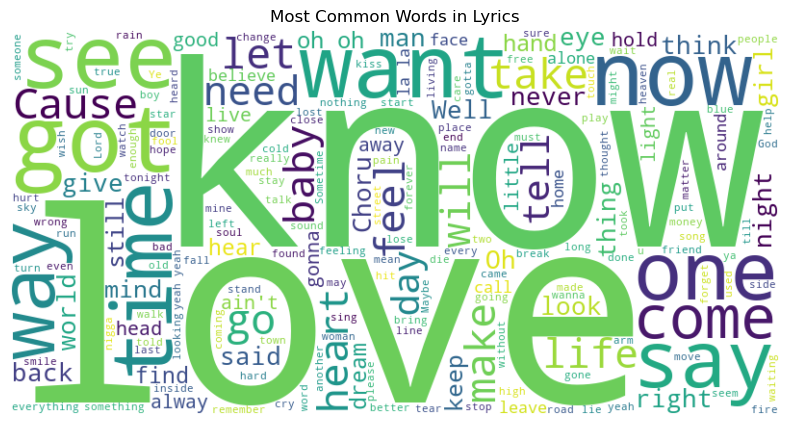

In [92]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Common Words in Lyrics")
plt.show()

**Data Preprocessing**

In [93]:
# download nltk data (Natural Language Toolkit)
nltk.download('punkt') # used for sentence tokenization.
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [94]:
stop_words = set(stopwords.words('english'))

In [95]:
def preprocess_text(text):
    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    # Convert to lowercase
    text = text.lower()
    # Tokenize and remove stopwords
    tokens = word_tokenize(text) 
    tokens = [word for word in tokens if word not in stop_words]  # ['love','heart' etc]
    return " ".join(tokens)  # joins the sentence with space "love heart"

In [96]:
# Apply preprocessing to lyrics
df['cleaned_text'] = df['text'].apply(preprocess_text)

In [97]:
df.head()

,artist,song,text,cleaned_text
0,Kelly Family,Say That You Love Me,Oh my baby if I could only evoke the love \r\...,oh baby could evoke love heart yearns like des...
1,Black Sabbath,Feels Good To Me,The chapter is opened and the pages are turned...,chapter opened pages turned writting say many ...
2,The Killers,Uncle Jonny,When everybody else refrains \r\nMy uncle Jon...,everybody else refrains uncle jonny cocaine he...
3,Willie Nelson,Down To Our Last Goodbye,This was my last mistake \r\nThat's all her h...,last mistake thats heart could take last goodb...
4,Heart,Unchained Melody,"Oh, my love, my darling \r\nI've hungered for...",oh love darling ive hungered touch alone lonel...


In [98]:
# Vectorization with TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_text'])

In [99]:
# Compute Cosine Similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [100]:
# Recommendation Function
def recommend_songs(song_name, cosine_sim=cosine_sim, df=df, top_n=7):
    # Find the index of the song
    idx = df[df['song'].str.lower() == song_name.lower()].index
    if len(idx) == 0:
        return "Song not found in the dataset!"   # can be reworked to compare for songs not present in the dataset
    idx = idx[0]

    # Get similarity scores (between 0 & 1) along with their indexes
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]

    # Get song indices
    song_indices = [i[0] for i in sim_scores]

    # Return top n similar songs
    return df[['artist', 'song']].iloc[song_indices]

In [101]:
df["song"][2]

'Uncle Jonny'

In [103]:
# Example Recommendation
print("\nRecommendations for the song 'For The First Time':")
recommendations = recommend_songs("Uncle Jonny") # df["song"][2]
print(recommendations)


Recommendations for the song 'For The First Time':
            artist                 song
5231  Alice Cooper          Fantasy Man
3211      Lou Reed     Looking For Love
6037       Ramones  Any Way You Want It
5918  Otis Redding              Respect
875     Beach Boys          Do It Again
7954  Neil Diamond          New Orleans
7070   Ray Charles             Hey Girl
